In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load the Data**

In [3]:
df = pd.read_csv("dataset.csv")  

**Check Basic Information**

In [5]:
df.head()

,date,demand,RRP,demand_pos_RRP,RRP_positive,demand_neg_RRP,RRP_negative,frac_at_neg_RRP,min_temperature,max_temperature,solar_exposure,rainfall,school_day,holiday
0,2015-01-01,99635.030,25.633696,97319.240,26.415953,2315.790,-7.240000,0.020833,13.3,26.9,23.6,0.0,N,Y
1,2015-01-02,129606.010,33.138988,121082.015,38.837661,8523.995,-47.809777,0.062500,15.4,38.8,26.8,0.0,N,N
2,2015-01-03,142300.540,34.564855,142300.540,34.564855,0.000,0.000000,0.000000,20.0,38.2,26.5,0.0,N,N
3,2015-01-04,104330.715,25.005560,104330.715,25.005560,0.000,0.000000,0.000000,16.3,21.4,25.2,4.2,N,N
4,2015-01-05,118132.200,26.724176,118132.200,26.724176,0.000,0.000000,0.000000,15.0,22.0,30.7,0.0,N,N


In [6]:
df.shape

(2106, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             2106 non-null   object 
 1   demand           2106 non-null   float64
 2   RRP              2106 non-null   float64
 3   demand_pos_RRP   2106 non-null   float64
 4   RRP_positive     2106 non-null   float64
 5   demand_neg_RRP   2106 non-null   float64
 6   RRP_negative     2106 non-null   float64
 7   frac_at_neg_RRP  2106 non-null   float64
 8   min_temperature  2106 non-null   float64
 9   max_temperature  2106 non-null   float64
 10  solar_exposure   2105 non-null   float64
 11  rainfall         2103 non-null   float64
 12  school_day       2106 non-null   object 
 13  holiday          2106 non-null   object 
dtypes: float64(11), object(3)
memory usage: 230.5+ KB


In [8]:
df.describe()

,demand,RRP,demand_pos_RRP,RRP_positive,demand_neg_RRP,RRP_negative,frac_at_neg_RRP,min_temperature,max_temperature,solar_exposure,rainfall
count,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2105.000000,2103.000000
mean,120035.476503,76.079554,119252.305055,76.553847,783.171448,-2.686052,0.008547,11.582289,20.413200,14.743373,1.505944
std,13747.993761,130.246805,14818.631319,130.114184,3578.920686,19.485432,0.039963,4.313711,6.288693,7.945527,4.307897
min,85094.375000,-6.076028,41988.240000,13.568986,0.000000,-342.220000,0.000000,0.600000,9.000000,0.700000,0.000000
25%,109963.650000,38.707040,109246.250000,39.117361,0.000000,0.000000,0.000000,8.500000,15.525000,8.200000,0.000000
50%,119585.912500,66.596738,119148.082500,66.869058,0.000000,0.000000,0.000000,11.300000,19.100000,12.700000,0.000000
75%,130436.006250,95.075012,130119.477500,95.130181,0.000000,0.000000,0.000000,14.600000,23.900000,20.700000,0.800000
max,170653.840000,4549.645105,170653.840000,4549.645105,57597.595000,0.000000,0.625000,28.000000,43.500000,33.300000,54.600000


In [9]:
df.isnull().sum()

date               0
demand             0
RRP                0
demand_pos_RRP     0
RRP_positive       0
demand_neg_RRP     0
RRP_negative       0
frac_at_neg_RRP    0
min_temperature    0
max_temperature    0
solar_exposure     1
rainfall           3
school_day         0
holiday            0
dtype: int64

In [51]:
#filling missing values
df['solar_exposure']=df['solar_exposure'].fillna(df['solar_exposure'].mode()[0])
df['rainfall']=df['rainfall'].fillna(df['rainfall'].mode()[0])

In [53]:
df.isnull().sum()

date               0
demand             0
RRP                0
demand_pos_RRP     0
RRP_positive       0
demand_neg_RRP     0
RRP_negative       0
frac_at_neg_RRP    0
min_temperature    0
max_temperature    0
solar_exposure     0
rainfall           0
school_day         0
holiday            0
dtype: int64

In [55]:
df.duplicated().sum()

0

**Analyze Categorical & Numerical Features**

In [14]:
##Identify categorical and numerical features:
cat_features = df.select_dtypes(include=['object']).columns
num_features = df.select_dtypes(include=['int64', 'float64']).columns

In [15]:
#Check unique values for categorical columns:
for col in cat_features:
    print(f"{col}: {df[col].nunique()} unique values")


date: 2106 unique values
school_day: 2 unique values
holiday: 2 unique values


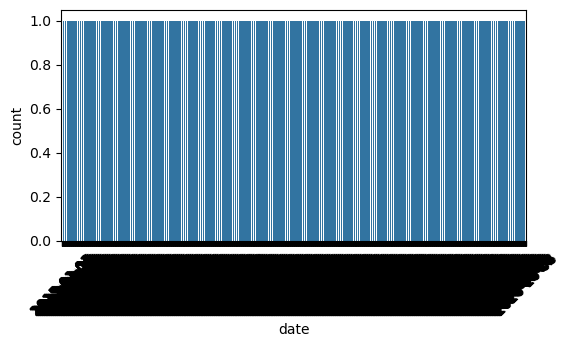

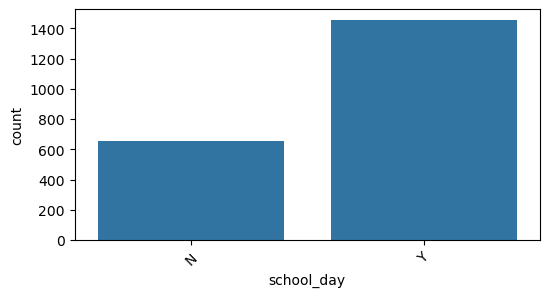

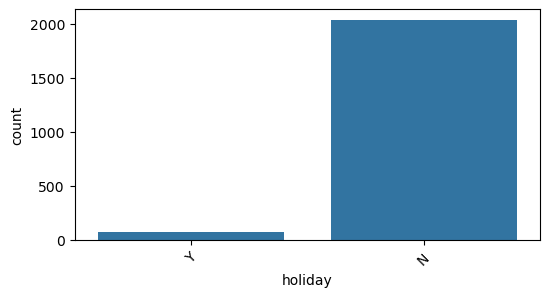

In [35]:
#Visualize categorical data:
for col in cat_features:
    plt.figure(figsize=(6, 3))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.show()

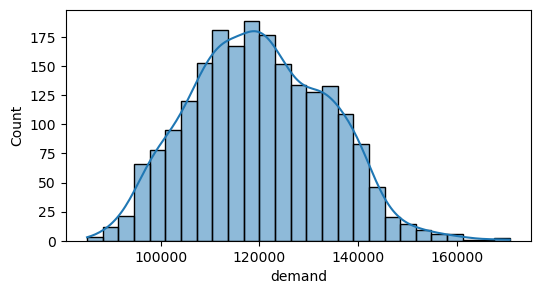

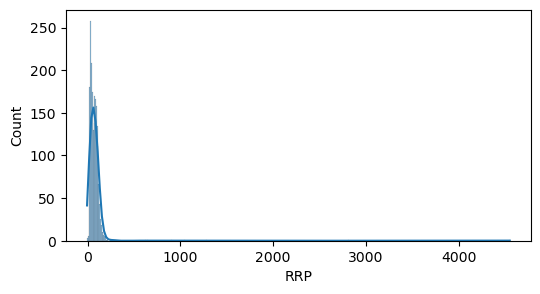

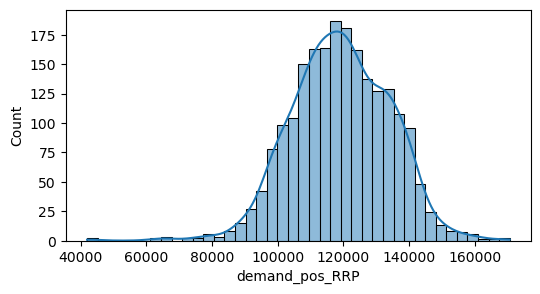

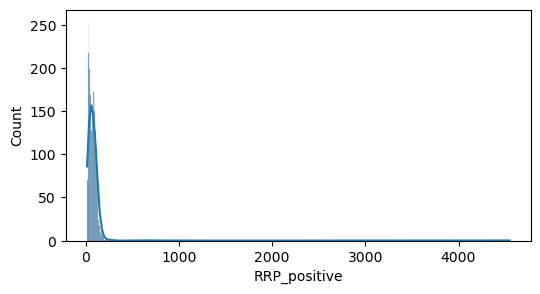

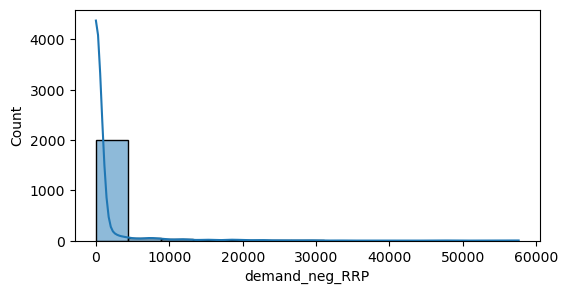

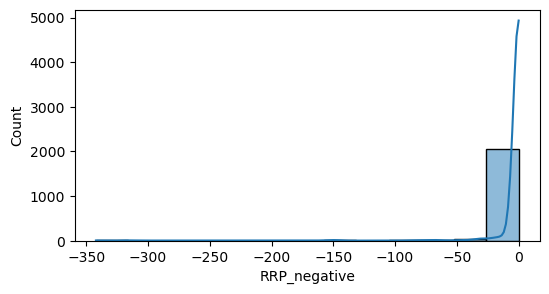

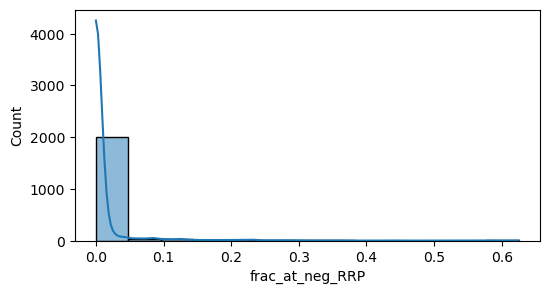

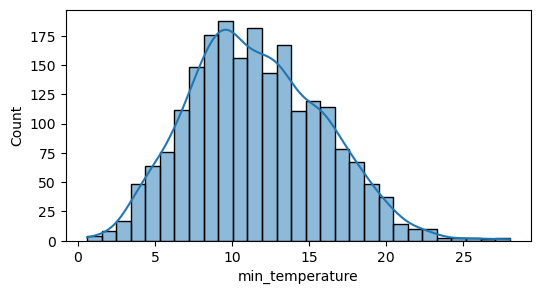

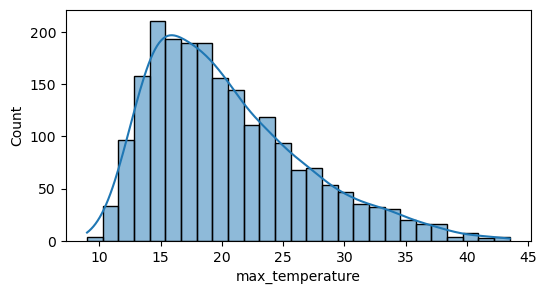

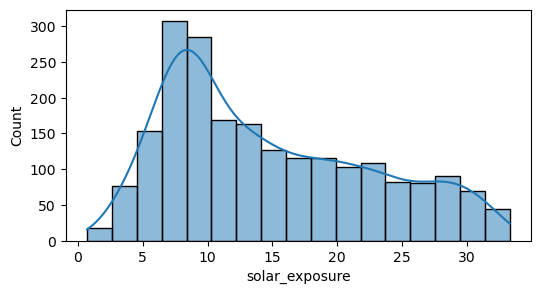

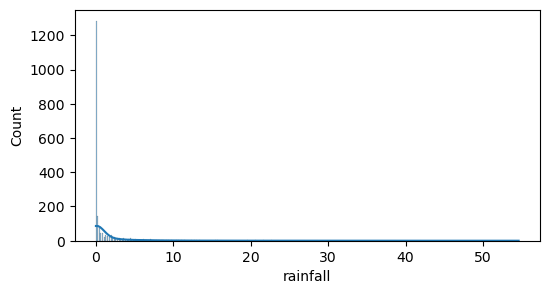

In [37]:
#Visualize numerical data distributions
for col in num_features:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col], kde=True)
    plt.show()


**Value counts**

<Axes: xlabel='school_day'>

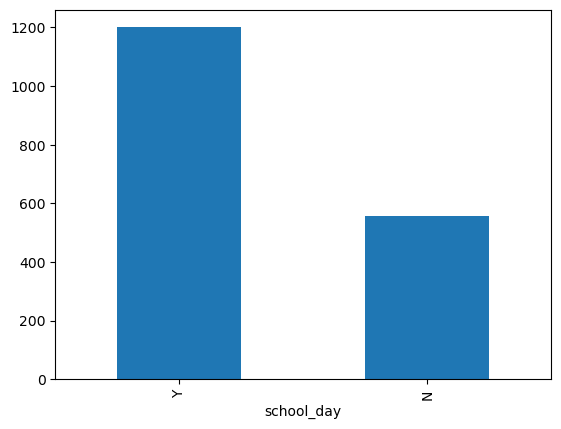

In [71]:
df['school_day'].value_counts().plot(kind='bar')

<Axes: xlabel='holiday'>

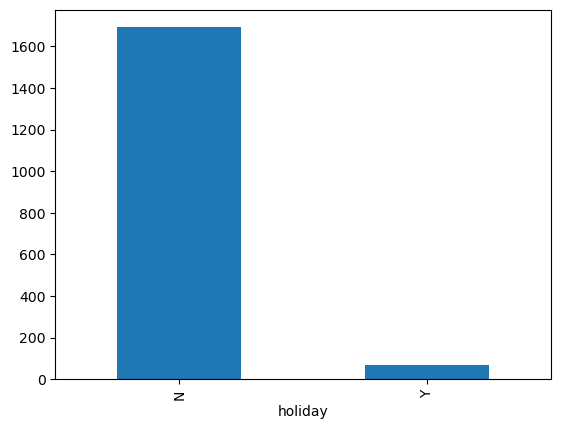

In [74]:
df['holiday'].value_counts().plot(kind='bar')

**Detect Outliers**

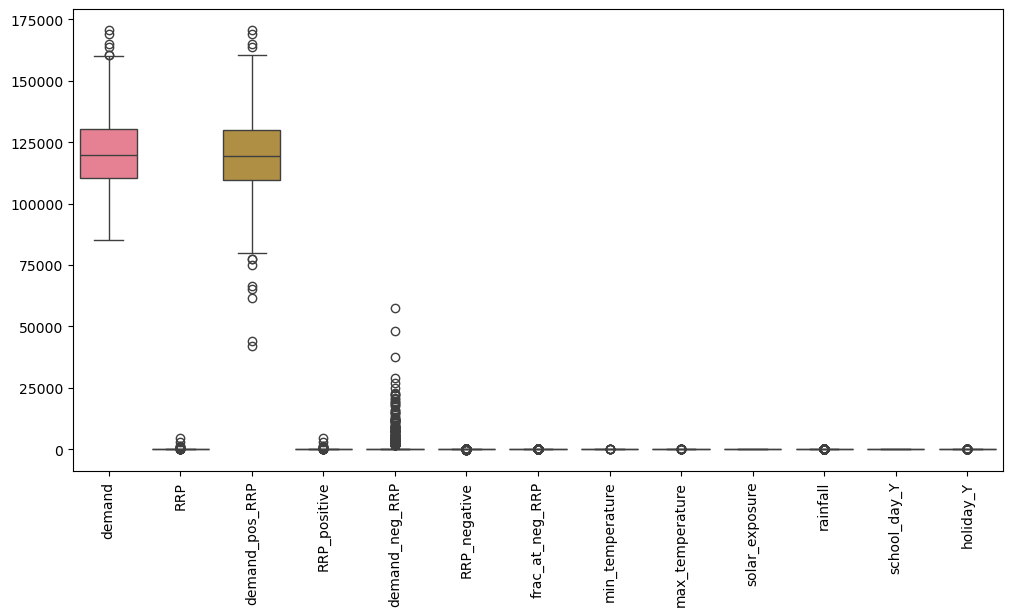

In [88]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

**Check Correlations**

In [82]:
#converting categorical values to numericals
df = pd.get_dummies(df, drop_first=True)

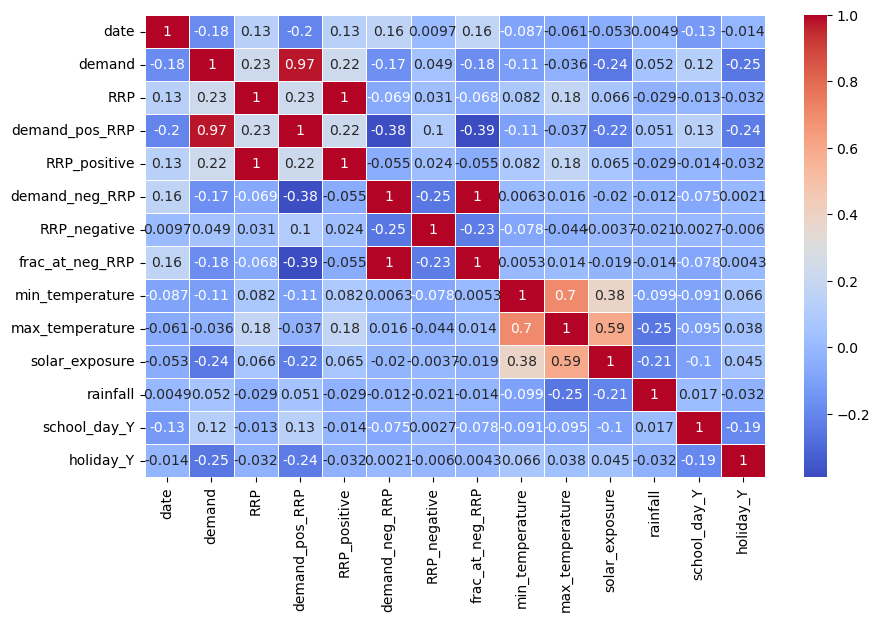

In [80]:
##Heatmap to see relationships:
df['date'] = pd.to_datetime(df['date'])
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.show()


In [94]:
print(df.info())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
Index: 1759 entries, 0 to 2105
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             1759 non-null   datetime64[ns]
 1   demand           1759 non-null   float64       
 2   RRP              1759 non-null   float64       
 3   demand_pos_RRP   1759 non-null   float64       
 4   RRP_positive     1759 non-null   float64       
 5   demand_neg_RRP   1759 non-null   float64       
 6   RRP_negative     1759 non-null   float64       
 7   frac_at_neg_RRP  1759 non-null   float64       
 8   min_temperature  1759 non-null   float64       
 9   max_temperature  1759 non-null   float64       
 10  solar_exposure   1759 non-null   float64       
 11  rainfall         1759 non-null   float64       
 12  school_day_Y     1759 non-null   bool          
 13  holiday_Y        1759 non-null   bool          
dtypes: bool(2), datetime64[ns](1), float64(11)
me